# Check test structures

Manual review of the generated DUD-Z benchmark cases — the **prompt, input, and
expected output** of every committed case, per target. Golds and probe answers were
computed independently of the chemistree tools (RDKit / numpy); this notebook reads the
committed case files and draws them so they can be eyeballed.

- **2D edits** — each instruction, with the start structure beside its computed gold.
- **3D probes** — the question and the computed answer, over the posed ligand.
- **3D decoration** — the Murcko scaffold the agent is seeded with (a `[WEAK]` note
  means the scaffold is nearly the whole ligand, so there is little to re-elaborate).

Run all cells (Kernel → Restart & Run All) to render the structures.

In [1]:
import json
from pathlib import Path

from IPython.display import display
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

# Works whether the notebook is opened from the repo root or from notebooks/.
BASE = Path("benchmarks") if Path("benchmarks").exists() else Path("../benchmarks")


def rows(target, kind):
    """The committed case rows for a target and track."""
    path = BASE / "cases" / f"{target}_{kind}.jsonl"
    return [json.loads(line) for line in path.read_text().splitlines()]


def flat2d(smiles):
    """A 2D depiction molecule from a SMILES."""
    return Chem.MolFromSmiles(smiles)


def posed_ligand(sdf_path):
    """The ligand with fresh 2D coordinates for a clean depiction."""
    mol = Chem.RemoveHs(Chem.MolFromMolFile(str(BASE.parent / sdf_path)))
    AllChem.Compute2DCoords(mol)
    return mol


def show_2d(target):
    for edit in rows(target, "2d"):
        print(f"[{edit['id']}] {edit['category']}: {edit['instruction']}")
        display(Draw.MolsToGridImage(
            [flat2d(edit["smiles"]), flat2d(edit["gold"])],
            legends=["start", "gold"], molsPerRow=2, subImgSize=(380, 300)))


def show_probes(target):
    probe_rows = rows(target, "3d_probes")
    display(Draw.MolToImage(posed_ligand(probe_rows[0]["ligand"]), size=(440, 300)))
    for probe in probe_rows:
        print(f"Q: {probe['question']}")
        print(f"   answer: {probe['answer']}")


def show_decoration(target):
    dec = rows(target, "3d_decoration")[0]
    scaffold = Chem.MolFromMolFile(str(BASE / "data" / target / "scaffold.sdf"))
    n_s = scaffold.GetNumHeavyAtoms()
    n_l = posed_ligand(dec["target"]).GetNumHeavyAtoms()
    weak = "  [WEAK: scaffold is nearly the whole ligand]" if (n_l - n_s) < 4 else ""
    print(f"instruction: {dec['instruction']}")
    print(f"scaffold {n_s}/{n_l} heavy atoms (stripped {n_l - n_s}){weak}")
    AllChem.Compute2DCoords(scaffold)
    display(Draw.MolToImage(scaffold, size=(440, 320)))

## EGFR

=== EGFR: 2D edits ===
[grow-cyclopropyl] growing: Add a cyclopropyl on the benzyl ring, para to the fluorine.


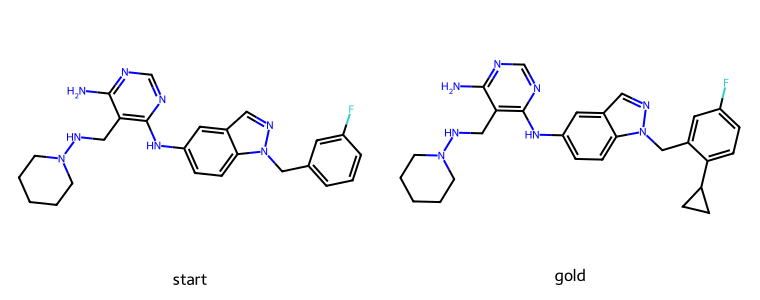

[core-piperazine] core_hopping: Change the terminal piperidine to a piperazine (replace the ring CH2 para to the ring nitrogen with an NH).


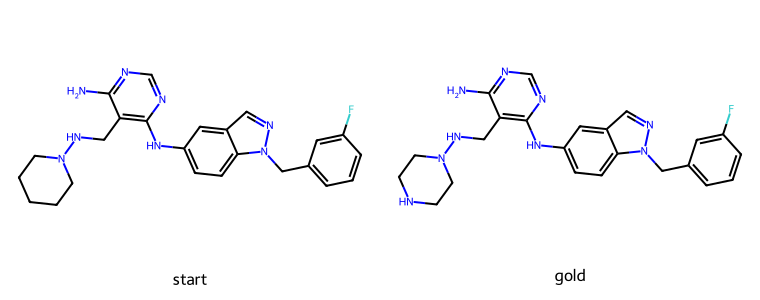

[core-triazine] core_hopping: Aza-substitute the aminopyrimidine CH between the two ring nitrogens, making a 1,3,5-triazine.


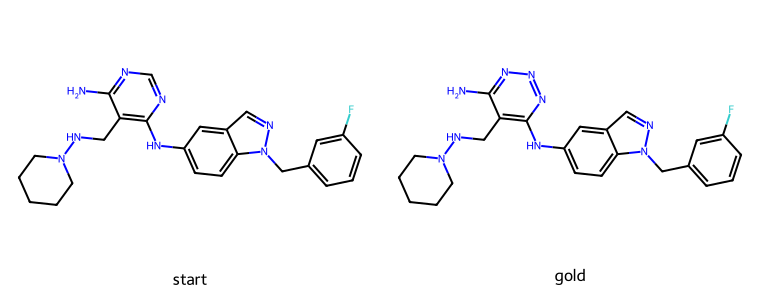

=== EGFR: 3D probes ===


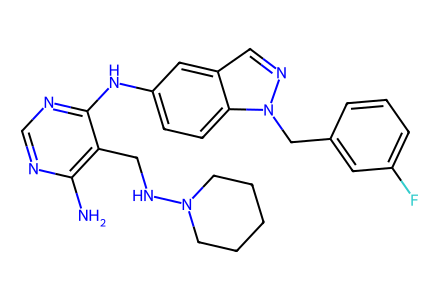

Q: Which receptor residue (give its name and number, e.g. ASP381) has an atom closest to the ligand's aminopyrimidine NH2?
   answer: MET793
Q: How many receptor residues have any atom within 4.0 Angstrom of the ligand's benzyl fluorine?
   answer: 5
=== EGFR: 3D decoration ===
instruction: Optimize the scaffold to improve predicted binding.
scaffold 31/33 heavy atoms (stripped 2)  [WEAK: scaffold is nearly the whole ligand]


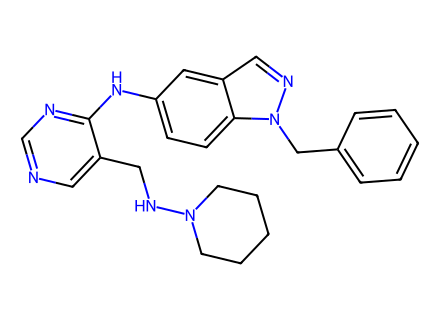

In [2]:
print('=== EGFR: 2D edits ===')
show_2d('egfr')
print('=== EGFR: 3D probes ===')
show_probes('egfr')
print('=== EGFR: 3D decoration ===')
show_decoration('egfr')

## AA2AR

=== AA2AR: 2D edits ===
[grow-nitrile] growing: Add a nitrile to the phenol ring, ortho to the hydroxyl.


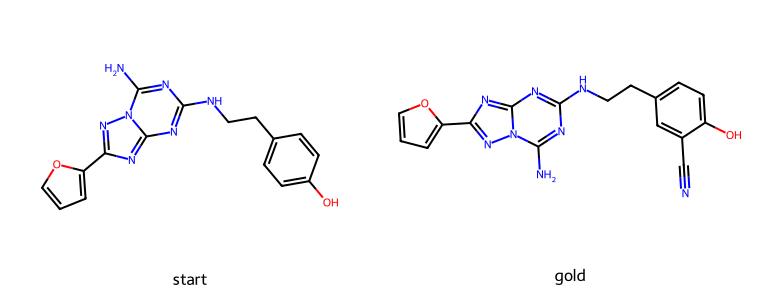

[core-benzofuran] core_hopping: Fuse a benzene onto the furan to make a benzofuran, keeping the attachment at the 2-position.


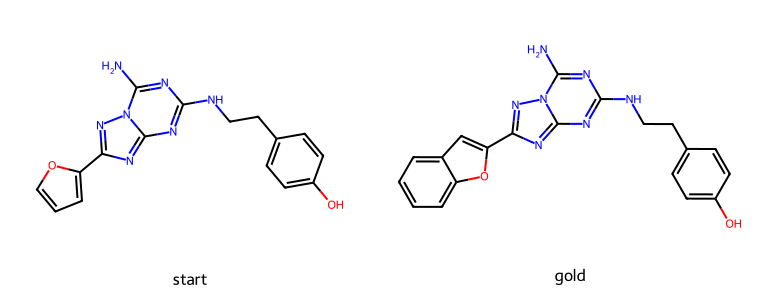

[sub-methoxy] substitution: O-methylate the phenol to a methyl ether (methoxy).


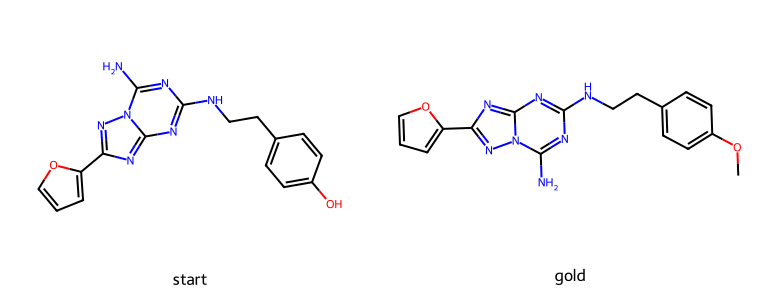

=== AA2AR: 3D probes ===


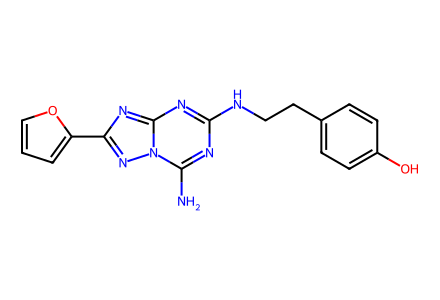

Q: How many receptor residues have any atom within 4.0 Angstrom of the ligand's exocyclic amino (NH2)?
   answer: 4
Q: How many receptor residues have any atom within 4.0 Angstrom of the ligand's furan ring?
   answer: 3
=== AA2AR: 3D decoration ===
instruction: Optimize the scaffold to improve predicted binding.
scaffold 23/25 heavy atoms (stripped 2)  [WEAK: scaffold is nearly the whole ligand]


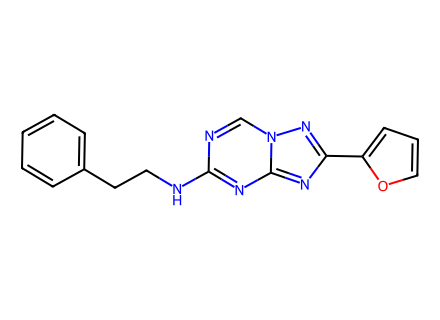

In [3]:
print('=== AA2AR: 2D edits ===')
show_2d('aa2ar')
print('=== AA2AR: 3D probes ===')
show_probes('aa2ar')
print('=== AA2AR: 3D decoration ===')
show_decoration('aa2ar')

## ANDR

=== ANDR: 2D edits ===
[grow-methyl] growing: Add a methyl at C4, the vinyl carbon of the A-ring enone.


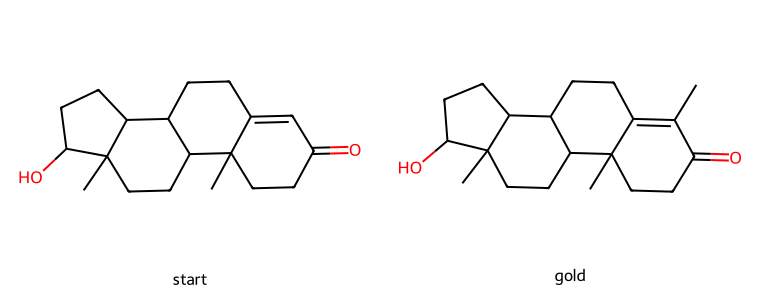

[sub-amine] substitution: Replace the 17-hydroxyl with a primary amine.


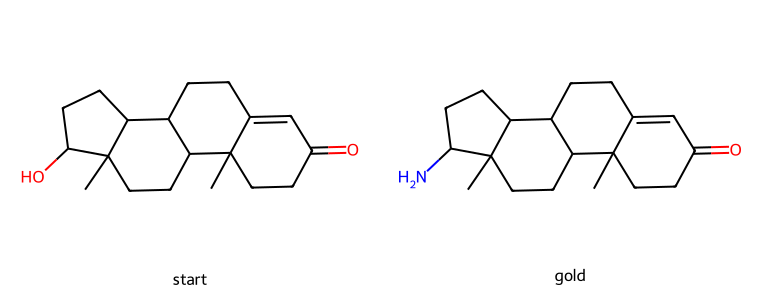

=== ANDR: 3D probes ===


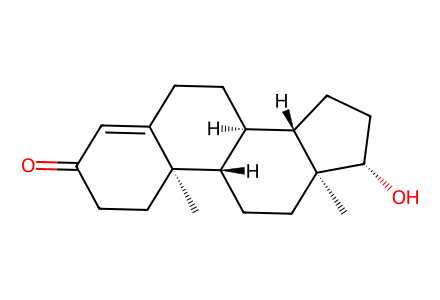

Q: How many receptor residues have any atom within 4.0 Angstrom of the ligand's A-ring ketone oxygen?
   answer: 5
Q: How many receptor residues have any atom within 4.0 Angstrom of the ligand's 17-hydroxyl?
   answer: 3
=== ANDR: 3D decoration ===
instruction: Optimize the scaffold to improve predicted binding.
scaffold 18/21 heavy atoms (stripped 3)  [WEAK: scaffold is nearly the whole ligand]


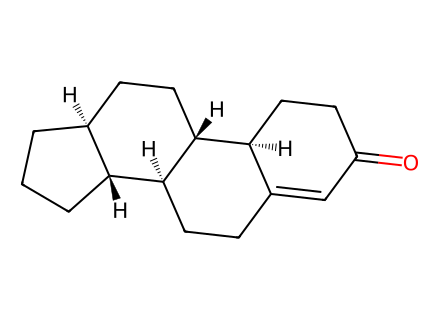

In [4]:
print('=== ANDR: 2D edits ===')
show_2d('andr')
print('=== ANDR: 3D probes ===')
show_probes('andr')
print('=== ANDR: 3D decoration ===')
show_decoration('andr')

## HIVPR

=== HIVPR: 2D edits ===
[grow-methoxy] growing: Add a methoxy para on the benzenesulfonyl ring.


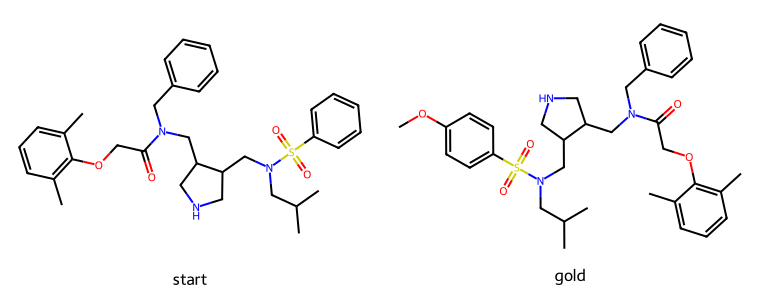

[core-naphthalene] core_hopping: Expand the N-benzyl phenyl to a 2-naphthyl (fuse a second benzene ring), keeping the methylene attachment.


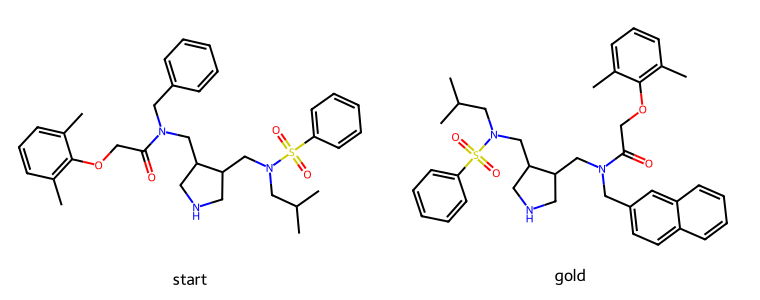

=== HIVPR: 3D probes ===


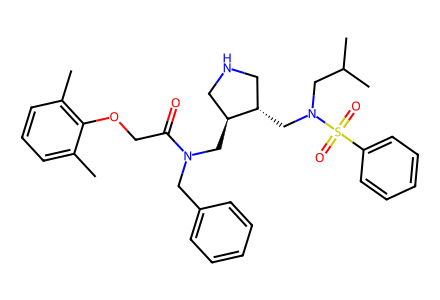

Q: Which receptor residue (give its name and number, e.g. ASP381) has an atom closest to the ligand's sulfonyl group?
   answer: ILE50
Q: How many receptor residues have any atom within 4.0 Angstrom of the ligand's sulfonyl group?
   answer: 2
=== HIVPR: 3D decoration ===
instruction: Optimize the scaffold to improve predicted binding.
scaffold 35/41 heavy atoms (stripped 6)


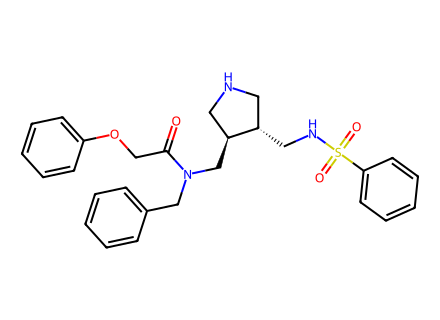

In [5]:
print('=== HIVPR: 2D edits ===')
show_2d('hivpr')
print('=== HIVPR: 3D probes ===')
show_probes('hivpr')
print('=== HIVPR: 3D decoration ===')
show_decoration('hivpr')

## FA10

=== FA10: 2D edits ===
[sub-bromo] substitution: Replace the chlorine on the naphthalene with a bromine.


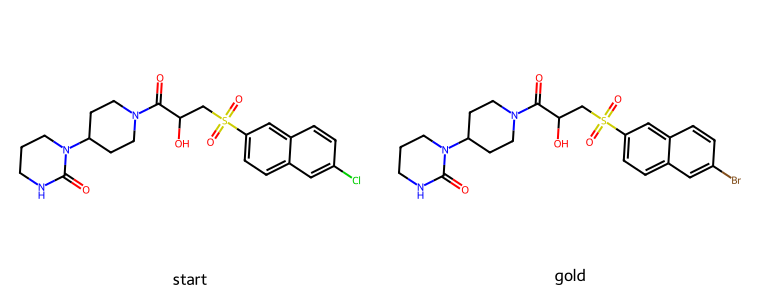

[sub-nmethyl] substitution: N-methylate the lactam N-H of the diazepanone ring.


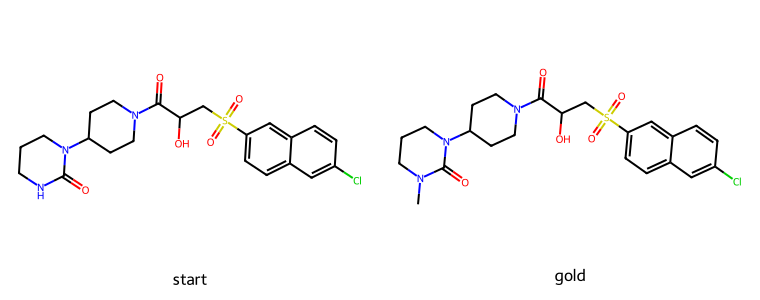

=== FA10: 3D probes ===


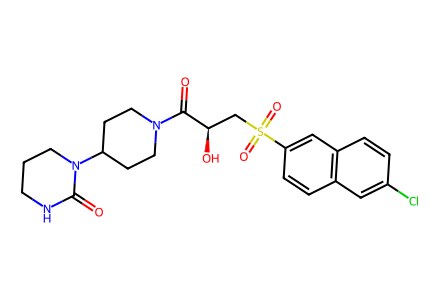

Q: Which receptor residue (give its name and number, e.g. ASP381) has an atom closest to the ligand's secondary alcohol hydroxyl?
   answer: GLY216
Q: How many receptor residues have any atom within 4.0 Angstrom of the ligand's naphthalene chlorine?
   answer: 6
=== FA10: 3D decoration ===
instruction: Optimize the scaffold to improve predicted binding.
scaffold 30/32 heavy atoms (stripped 2)  [WEAK: scaffold is nearly the whole ligand]


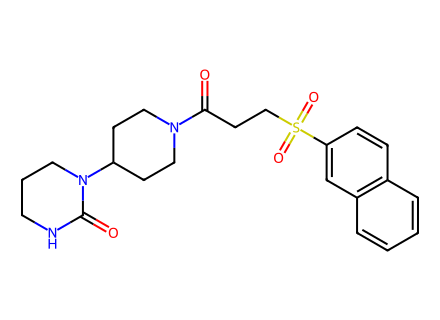

In [6]:
print('=== FA10: 2D edits ===')
show_2d('fa10')
print('=== FA10: 3D probes ===')
show_probes('fa10')
print('=== FA10: 3D decoration ===')
show_decoration('fa10')

## HDAC8

=== HDAC8: 2D edits ===
[grow-oxetane] growing: Add an oxetan-3-yl para on the phenyl of the phenylacetyl group.


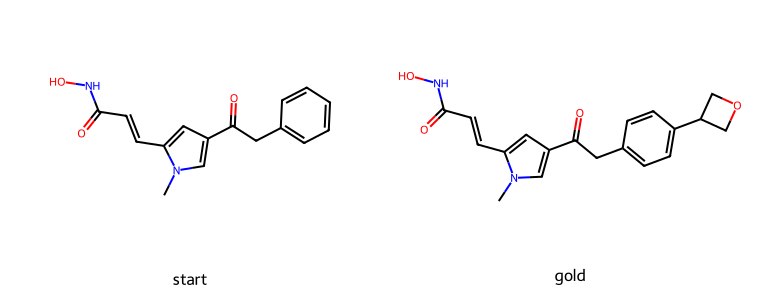

[core-thiophene] core_hopping: Replace the phenacyl phenyl with a 2-thienyl (contract the benzene to a thiophene), keeping the methylene attachment.


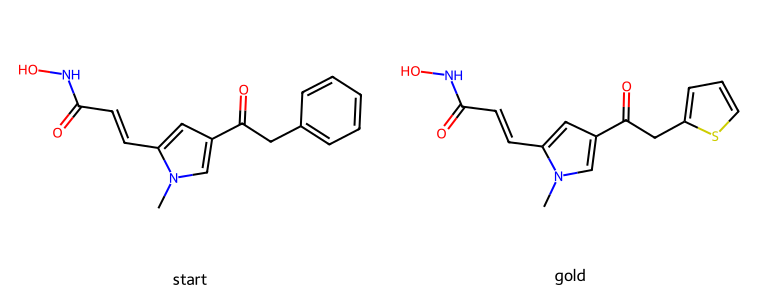

=== HDAC8: 3D probes ===


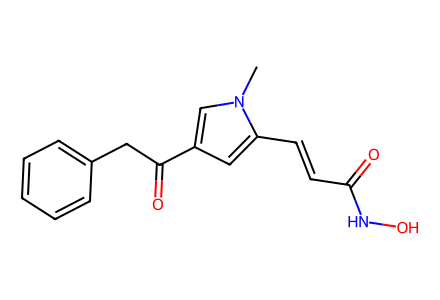

Q: How many receptor residues have any atom within 4.0 Angstrom of the ligand's hydroxamic acid?
   answer: 6
Q: How many histidine residues have any atom within 4.0 Angstrom of the ligand's hydroxamic acid?
   answer: 3
=== HDAC8: 3D decoration ===
instruction: Optimize the scaffold to improve predicted binding.
scaffold 14/21 heavy atoms (stripped 7)


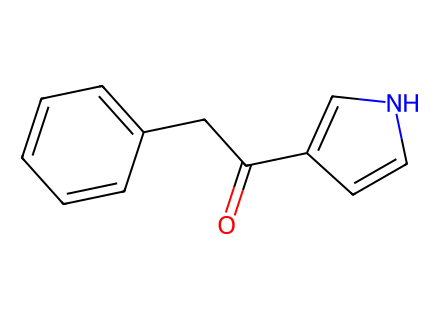

In [7]:
print('=== HDAC8: 2D edits ===')
show_2d('hdac8')
print('=== HDAC8: 3D probes ===')
show_probes('hdac8')
print('=== HDAC8: 3D decoration ===')
show_decoration('hdac8')

## PARP1

=== PARP1: 2D edits ===
[grow-fluoro] growing: Add a second fluorine on the fluorophenyl ring, para to the fluorine.


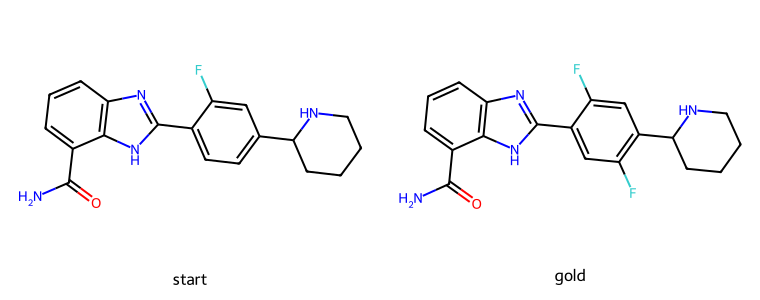

[core-piperazine] core_hopping: Change the piperidine to a piperazine (replace the ring CH2 para to the nitrogen with an NH).


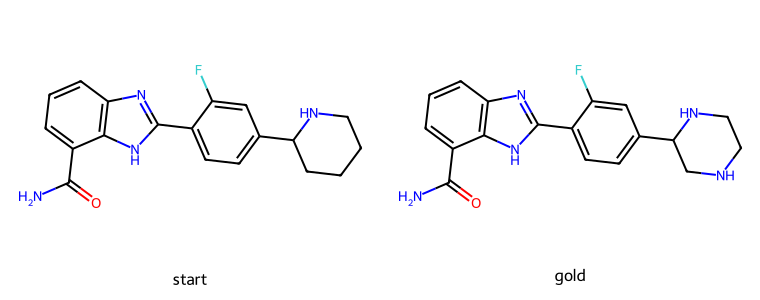

=== PARP1: 3D probes ===


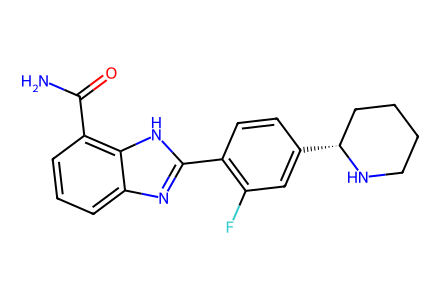

Q: Which receptor residue (give its name and number, e.g. ASP381) has an atom closest to the ligand's primary carboxamide?
   answer: GLY202
Q: How many receptor residues have any atom within 4.0 Angstrom of the ligand's primary carboxamide?
   answer: 4
=== PARP1: 3D decoration ===
instruction: Optimize the scaffold to improve predicted binding.
scaffold 21/25 heavy atoms (stripped 4)


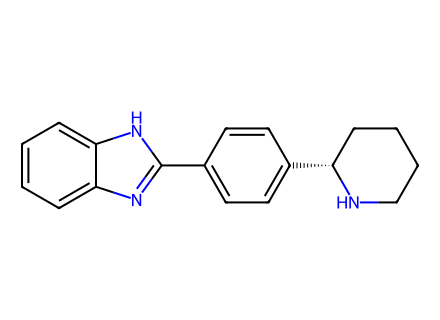

In [8]:
print('=== PARP1: 2D edits ===')
show_2d('parp1')
print('=== PARP1: 3D probes ===')
show_probes('parp1')
print('=== PARP1: 3D decoration ===')
show_decoration('parp1')

## HS90A

=== HS90A: 2D edits ===
[sub-nitrile] substitution: Replace the ring fluorine with a nitrile.


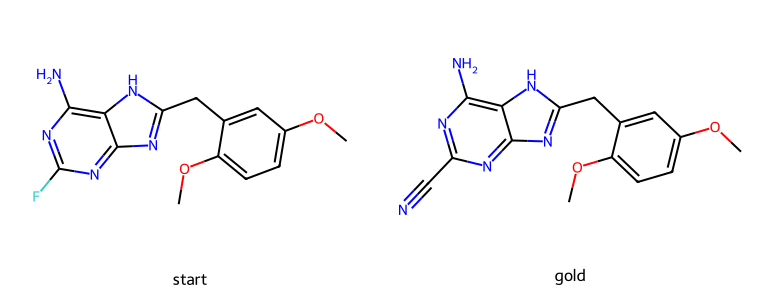

[grow-dimethylamino] growing: Add a dimethylamino on the dimethoxybenzene, ortho to the methylene link.


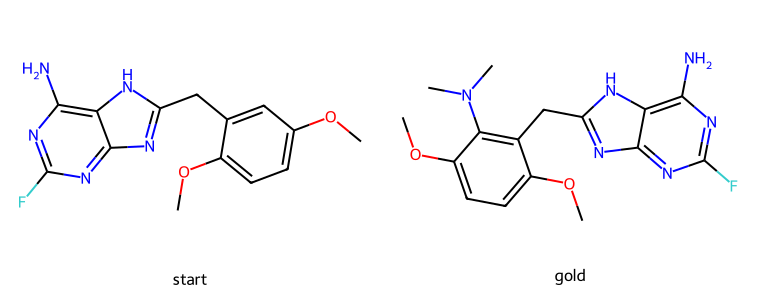

=== HS90A: 3D probes ===


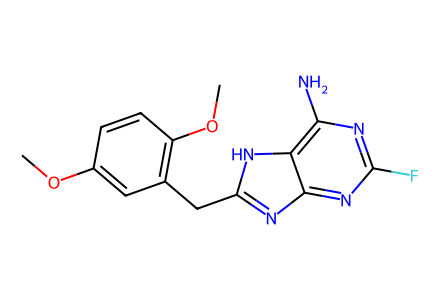

Q: Which receptor residue (give its name and number, e.g. ASP381) has an atom closest to the ligand's aminopyrimidine NH2?
   answer: ASP93
Q: How many receptor residues have any atom within 4.0 Angstrom of the ligand's ring fluorine?
   answer: 5
=== HS90A: 3D decoration ===
instruction: Optimize the scaffold to improve predicted binding.
scaffold 16/22 heavy atoms (stripped 6)


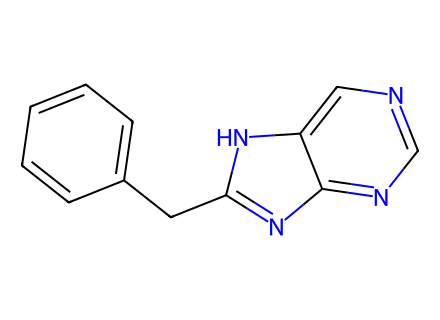

In [9]:
print('=== HS90A: 2D edits ===')
show_2d('hs90a')
print('=== HS90A: 3D probes ===')
show_probes('hs90a')
print('=== HS90A: 3D decoration ===')
show_decoration('hs90a')

## ADA

=== ADA: 2D edits ===
[core-triazole] core_hopping: Aza-substitute the imidazole C2 (between the two ring nitrogens) to a nitrogen, making a 1,2,3-triazole.


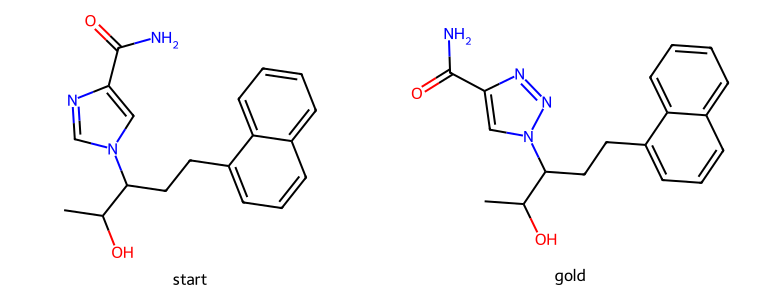

[sub-nitrile] substitution: Dehydrate the imidazole carboxamide to a nitrile.


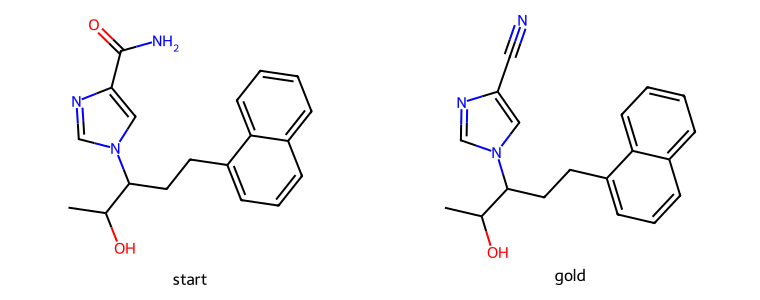

=== ADA: 3D probes ===


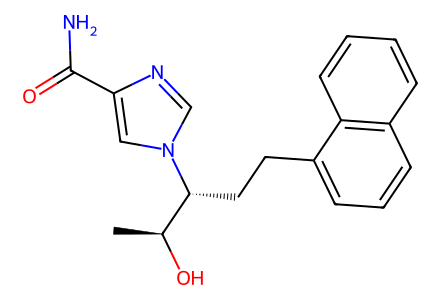

Q: Which receptor residue (give its name and number, e.g. ASP381) has an atom closest to the ligand's imidazole carboxamide?
   answer: ASP296
Q: How many receptor residues have any atom within 4.0 Angstrom of the ligand's secondary alcohol hydroxyl?
   answer: 5
=== ADA: 3D decoration ===
instruction: Optimize the scaffold to improve predicted binding.
scaffold 18/24 heavy atoms (stripped 6)


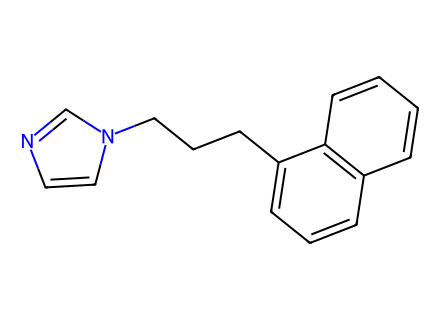

In [10]:
print('=== ADA: 2D edits ===')
show_2d('ada')
print('=== ADA: 3D probes ===')
show_probes('ada')
print('=== ADA: 3D decoration ===')
show_decoration('ada')

## NRAM

=== NRAM: 2D edits ===
[core-tetrazole] core_hopping: Replace the benzoic-acid carboxyl with a tetrazole bioisostere.


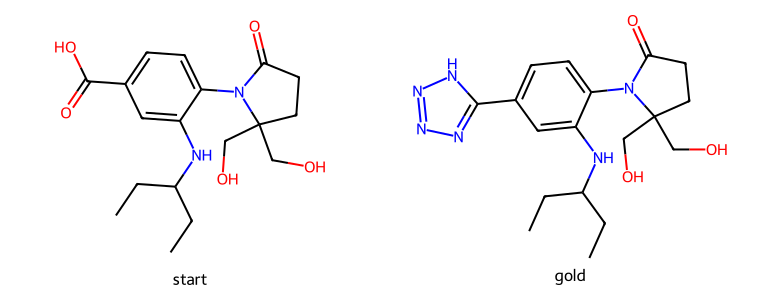

[sub-nmethyl] substitution: N-methylate the secondary aniline nitrogen.


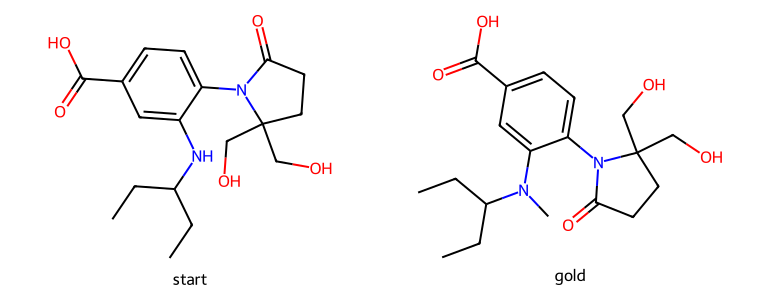

=== NRAM: 3D probes ===


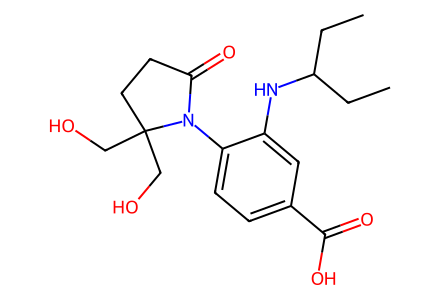

Q: How many receptor residues have any atom within 4.0 Angstrom of the ligand's carboxylic acid?
   answer: 4
Q: How many arginine residues have any atom within 4.0 Angstrom of the ligand's carboxylic acid?
   answer: 3
=== NRAM: 3D decoration ===
instruction: Optimize the scaffold to improve predicted binding.
scaffold 12/25 heavy atoms (stripped 13)


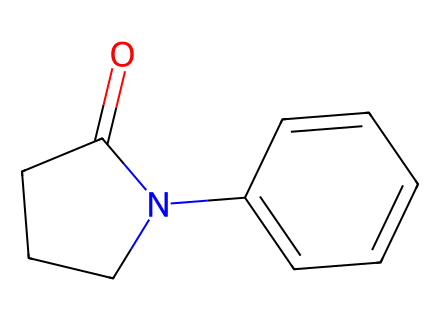

In [11]:
print('=== NRAM: 2D edits ===')
show_2d('nram')
print('=== NRAM: 3D probes ===')
show_probes('nram')
print('=== NRAM: 3D decoration ===')
show_decoration('nram')